In [1]:
# Las dependencias ya están instaladas en el entorno del notebook.

In [2]:
import os
import pandas as pd
import numpy as np
import re
import seaborn as sns
import nltk
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# La raiz del laboratorio se resuelve desde el directorio de trabajo para que el
# cuaderno corra en cualquier maquina, no solo donde se ejecuto la primera vez.
BASE_PATH = os.getcwd() if os.path.basename(os.getcwd()) == 'Lab5' else 'Lab5'
DATA_PATH = f'{BASE_PATH}/data'
PROCESSED = f'{BASE_PATH}/processed'
os.makedirs(PROCESSED, exist_ok=True)

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


### Preprocesamiento

In [3]:
#config
stop_words = set(stopwords.words('english'))
try:
  lemmatizer = WordNetLemmatizer()
  lemmatizer.lemmatize('tests')
except LookupError:
  class IdentityLemmatizer:
    def lemmatize(self, token): return token
  lemmatizer = IdentityLemmatizer()

def emojis(text):
  emoji_pattern = re.compile("["
    u"\U0001F600-\U0001F64F"  #emojis varios
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    "]+", flags=re.UNICODE)
  return emoji_pattern.sub(r'', text)

def preprocesamiento(text):
  if pd.isna(text):
    return ""
  #minusculas
  text = text.lower()
  #eliemiar url
  text = re.sub(r'http\S+|www.\S+|https\S+', '', text)
  #car especiales, puntuacion, etc
  text = re.sub(r'[^a-zA-Z\s]', '', text)
  #espacios mutiples
  text = re.sub(r'\s+', ' ', text).strip()
  #emojis
  text = emojis(text)
  #tok
  tokens = text.split()
  #lemmatizaicon
  tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
  #recontrusccion
  return ' '.join(tokens)

def pre_df(df, text_col='text', keyword_col='keyword'):
    df = df.copy()

    #si keyword, comb con texto
    if keyword_col in df.columns:
        df['full_text'] = df[keyword_col].fillna('') + ' ' + df[text_col].fillna('')
        df['cleaned_text'] = df['full_text'].apply(preprocesamiento)
    else:
        df['cleaned_text'] = df[text_col].apply(preprocesamiento)

    # Métricas adicionales
    df['word_count'] = df['cleaned_text'].str.split().str.len()
    df['text_length_original'] = df[text_col].str.len()
    df['text_length_cleaned'] = df['cleaned_text'].str.len()

    return df


train_df = pd.read_csv(f'{DATA_PATH}/train.csv')
test_df = pd.read_csv(f'{DATA_PATH}/test.csv')
print("\n--- DATOS CARGADOS ---")
print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")

print("\n--- INFO DATASET ---")
print(train_df.info())
print("\n--- FRAGMENTO ---")
print(train_df.head())

print("\n=== PREPROCESAMIENTO DATOS ===")
train_df = pre_df(train_df, text_col='text', keyword_col='keyword')
test_df = pre_df(test_df, text_col='text', keyword_col='keyword')
print(".... Preprocesamiento completado ....")
print(f"Train: {train_df.shape}\nTest: {test_df.shape}")


train_df.to_csv(f'{PROCESSED}/train_preprocessed.csv', index=False)
test_df.to_csv(f'{PROCESSED}/test_preprocessed.csv', index=False)

print(f"Datos preprocesados en {PROCESSED}")


--- DATOS CARGADOS ---
Train: (7613, 5)
Test: (3263, 4)

--- INFO DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB
None

--- FRAGMENTO ---
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       

### Analisis exploratorio

=== ANALISIS EXPLORATORIO ===

ESTADISTICAS PREPROCESAMIENTO:
Prom. caracteres originales: 101.04
Prom. caracteres procesados: 73.00
Reduccion promedio: 27.75%
Prom. palabras/tweet: 10.11
Max. palabras en un tweet: 24
Min. palabras en un tweet: 1

--- EJEMPLOS ---

Tweet 1:
Original: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Keyword: nan
Procesado: deeds reason earthquake may allah forgive us
++++++++++++++++++++

Tweet 2:
Original: Forest fire near La Ronge Sask. Canada
Keyword: nan
Procesado: forest fire near la ronge sask canada
++++++++++++++++++++

Tweet 3:
Original: All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
Keyword: nan
Procesado: residents asked shelter place notified officers evacuation shelter place orders expected
++++++++++++++++++++

Tweet 4:
Original: 13,000 people receive #wildfires evacuation orders in California 
Keyword: nan
Procesado: people receive 

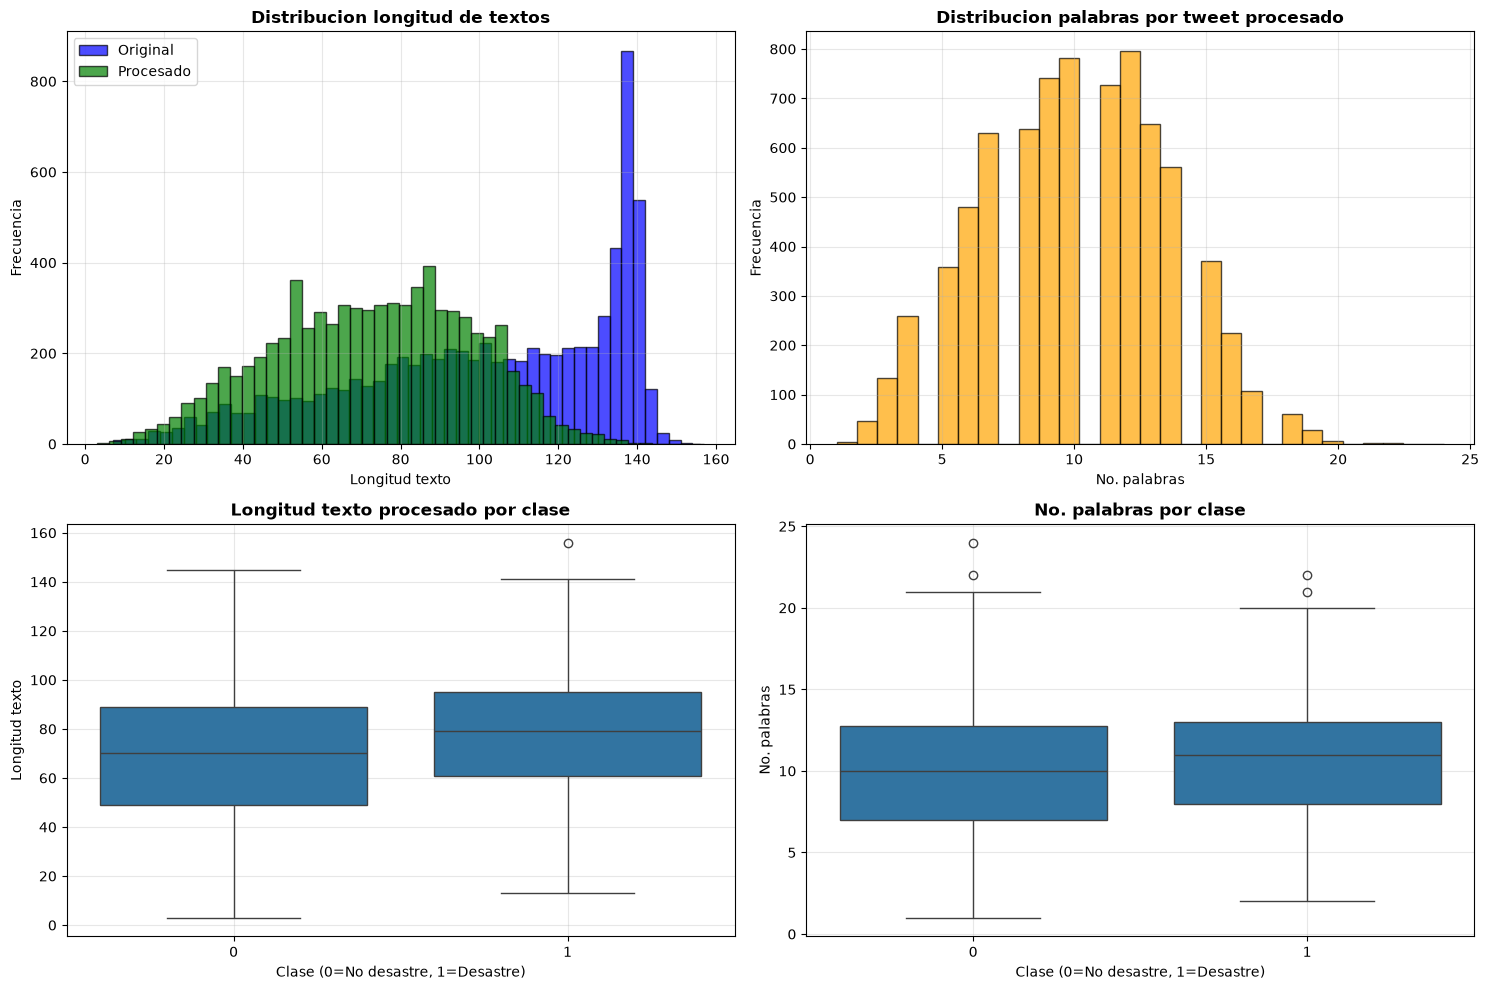

In [4]:
print("=== ANALISIS EXPLORATORIO ===")

print("\nESTADISTICAS PREPROCESAMIENTO:")
print(f"Prom. caracteres originales: {train_df['text_length_original'].mean():.2f}")
print(f"Prom. caracteres procesados: {train_df['text_length_cleaned'].mean():.2f}")
print(f"Reduccion promedio: {((train_df['text_length_original'].mean() - train_df['text_length_cleaned'].mean()) / train_df['text_length_original'].mean() * 100):.2f}%")
print(f"Prom. palabras/tweet: {train_df['word_count'].mean():.2f}")
print(f"Max. palabras en un tweet: {train_df['word_count'].max()}")
print(f"Min. palabras en un tweet: {train_df['word_count'].min()}")

print("\n--- EJEMPLOS ---")
sample_tweets = train_df[['text', 'keyword', 'cleaned_text']].head(5)
for idx, row in sample_tweets.iterrows():
    print(f"\nTweet {idx+1}:")
    print(f"Original: {row['text']}")
    print(f"Keyword: {row['keyword']}")
    print(f"Procesado: {row['cleaned_text']}")
    print("+"*20)

#graficas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

#hist. long textos
axes[0, 0].hist(train_df['text_length_original'], bins=50, alpha=0.7, label='Original', color='blue', edgecolor='black')
axes[0, 0].hist(train_df['text_length_cleaned'], bins=50, alpha=0.7, label='Procesado', color='green', edgecolor='black')
axes[0, 0].set_title('Distribucion longitud de textos', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Longitud texto')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

#hist. palabras/tweet
axes[0, 1].hist(train_df['word_count'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribucion palabras por tweet procesado', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('No. palabras')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(True, alpha=0.3)

#long/clase
sns.boxplot(data=train_df, x='target', y='text_length_cleaned', ax=axes[1, 0])
axes[1, 0].set_title('Longitud texto procesado por clase', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Clase (0=No desastre, 1=Desastre)')
axes[1, 0].set_ylabel('Longitud texto')
axes[1, 0].grid(True, alpha=0.3)

#palabras/clase
sns.boxplot(data=train_df, x='target', y='word_count', ax=axes[1, 1])
axes[1, 1].set_title('No. palabras por clase', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Clase (0=No desastre, 1=Desastre)')
axes[1, 1].set_ylabel('No. palabras')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/preprocessing_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


=== ANALISIS FRECUENCIA PALABRAS ===
Top 15 palabras - Desastres:
  fire          (191)
  news          (140)
  disaster      (132)
  police        (128)
  via           (121)
  california    (111)
  suicide       (110)
  amp           (107)
  people        (105)
  storm         (103)
  wildfire      (98)
  crash         (96)
  attack        (94)
  bombing       (94)
  killed        (93)

Top 15 palabras - No Desastres:
  like          (253)
  im            (248)
  amp           (193)
  new           (170)
  get           (163)
  dont          (154)
  one           (128)
  body          (113)
  emergency     (104)
  via           (99)
  fire          (99)
  would         (97)
  video         (96)
  people        (91)
  love          (90)


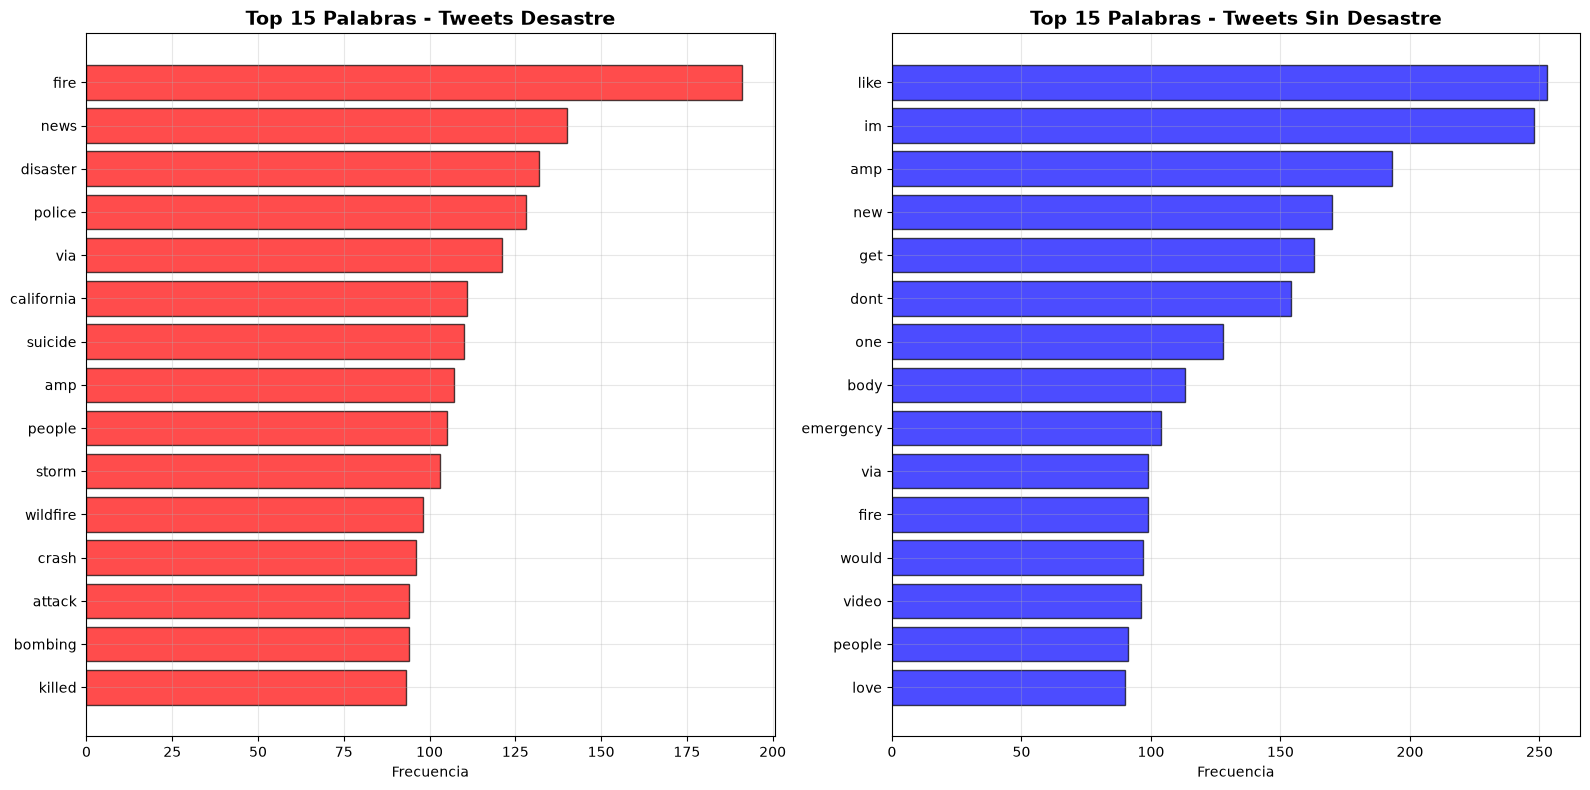

=== PALABRAS DIFERENCIALES POR CLASE ===
Palabras con mayor asociacion a desastres:
  fire            5.0% desastres | 1.6% no desastres (diff: +3.5%)
  california      3.3% desastres | 0.1% no desastres (diff: +3.2%)
  suicide         3.2% desastres | 0.1% no desastres (diff: +3.0%)
  news            4.1% desastres | 1.3% no desastres (diff: +2.8%)
  killed          2.8% desastres | 0.1% no desastres (diff: +2.7%)
  hiroshima       2.7% desastres | 0.0% no desastres (diff: +2.6%)
  police          3.0% desastres | 0.8% no desastres (diff: +2.2%)
  disaster        3.0% desastres | 0.8% no desastres (diff: +2.2%)
  wildfire        2.2% desastres | 0.1% no desastres (diff: +2.1%)
  fires           2.5% desastres | 0.4% no desastres (diff: +2.1%)
  mh              2.1% desastres | 0.0% no desastres (diff: +2.1%)
  pm              2.4% desastres | 0.3% no desastres (diff: +2.1%)
  bombing         2.0% desastres | 0.0% no desastres (diff: +2.0%)
  train           2.3% desastres | 0.3% no de

In [5]:
print("=== ANALISIS FRECUENCIA PALABRAS ===")

disaster = train_df[train_df['target'] == 1]['cleaned_text']
no_disaster = train_df[train_df['target'] == 0]['cleaned_text']

def palabras_frecuentes(text_series, n=15):
  palabras_total = ' '.join(text_series).split()
  counter = Counter(palabras_total)
  return counter.most_common(n)

top_disaster = palabras_frecuentes(disaster, 15)
top_no_disaster = palabras_frecuentes(no_disaster, 15)

print("Top 15 palabras - Desastres:")
for word, count in top_disaster:
    print(f"  {word:13} ({count})")

print("\nTop 15 palabras - No Desastres:")
for word, count in top_no_disaster:
    print(f"  {word:13} ({count})")

#graficas
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

#desasdtes
words_d, counts_d = zip(*top_disaster)
axes[0].barh(words_d, counts_d, color='red', alpha=0.7, edgecolor='black')
axes[0].set_title('Top 15 Palabras - Tweets Desastre', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frecuencia')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)

#no desaastres
words_nd, counts_nd = zip(*top_no_disaster)
axes[1].barh(words_nd, counts_nd, color='blue', alpha=0.7, edgecolor='black')
axes[1].set_title('Top 15 Palabras - Tweets Sin Desastre', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frecuencia')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/top_words_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


print("=== PALABRAS DIFERENCIALES POR CLASE ===")
def frecuencia(text_series):
  word_count = Counter()
  total_tweets = len(text_series)

  for text in text_series:
    unique_words = set(text.split())
    word_count.update(unique_words)

  return {word: count/total_tweets*100 for word, count in word_count.items()}

disaster_word_freq = frecuencia(disaster)
no_disaster_word_freq = frecuencia(no_disaster)

all_words = set(disaster_word_freq.keys()) | set(no_disaster_word_freq.keys())
word_diff_pct = {}

for word in all_words:
    d_pct = disaster_word_freq.get(word, 0)
    nd_pct = no_disaster_word_freq.get(word, 0)
    word_diff_pct[word] = d_pct - nd_pct

#ordenar
disaster_specific = sorted([(v, k) for k, v in word_diff_pct.items() if v > 0], reverse=True)[:15]
no_disaster_specific = sorted([(v, k) for k, v in word_diff_pct.items() if v < 0])[:15]

print("Palabras con mayor asociacion a desastres:")
for diff, word in disaster_specific:
    d_pct = disaster_word_freq[word]
    nd_pct = no_disaster_word_freq.get(word, 0)
    print(f"  {word:15} {d_pct:.1f}% desastres | {nd_pct:.1f}% no desastres (diff: {diff:+.1f}%)")

print("Palabras con mayor asociacion a no desastres:")
for diff, word in no_disaster_specific:
    d_pct = disaster_word_freq.get(word, 0)
    nd_pct = no_disaster_word_freq[word]
    print(f"  {word:15} {d_pct:.1f}% desastres | {nd_pct:.1f}% no desastres (diff: {diff:+.1f}%)")

=== ANALISIS BIGRAMAS Y TRIGRAMAS ===

--- BIGRAMAS MAS FRECUENTES ---

Desastres:
                    ngram  frecuencia
12         suicide bomber          59
7     northern california          41
8               oil spill          38
1       burning buildings          35
2     california wildfire          34
13        suicide bombing          34
0        bomber detonated          30
3            confirmed mh          29
5             homes razed          29
9   outbreak legionnaires          29
14                 yr old          29
4          detonated bomb          28
6            latest homes          28
10            pkk suicide          28
11         razed northern          28

No Desastres:
                   ngram  frecuencia
5             cross body          38
14         youtube video          36
8          liked youtube          35
7              full read          28
0               body bag          27
1           body bagging          23
3      burning buildings          2

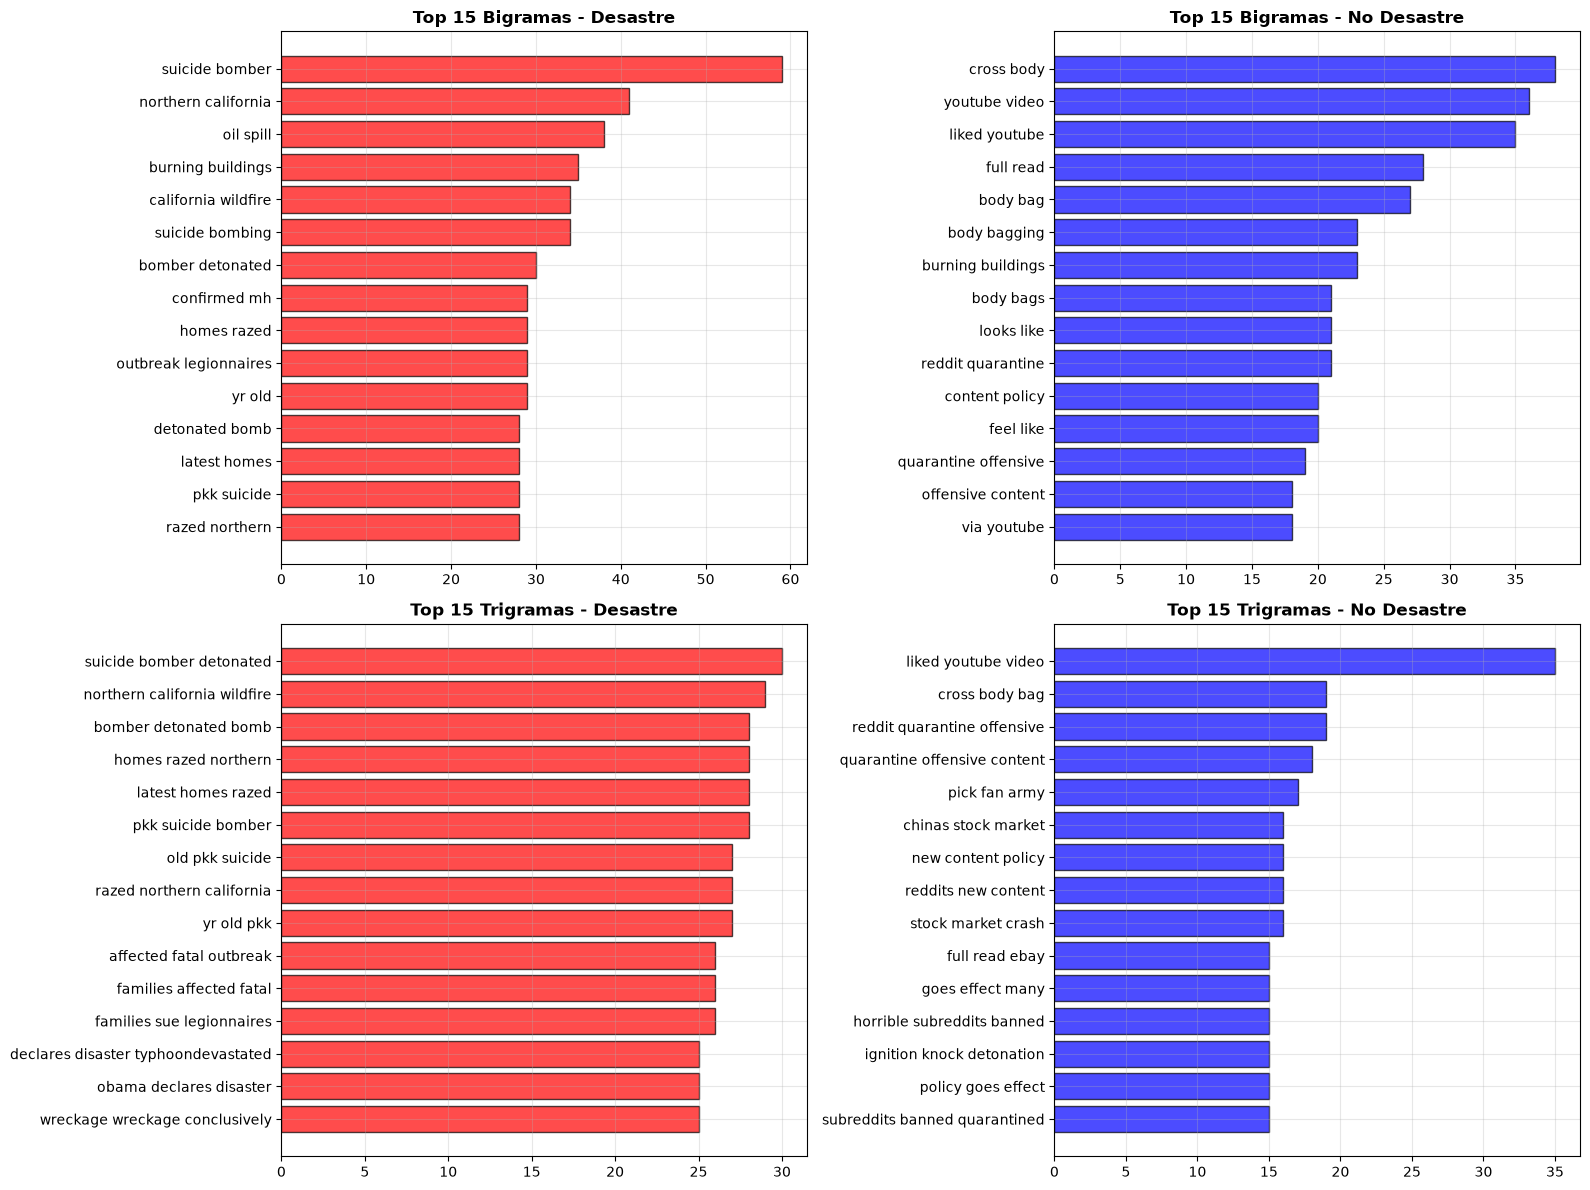

In [6]:
#bigramas y trigramas
print("=== ANALISIS BIGRAMAS Y TRIGRAMAS ===")

def get_ngrams(text_series, ngram_range=(2, 2), top_n=20):
    vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=top_n)
    X = vectorizer.fit_transform(text_series)
    ngram_freq = X.toarray().sum(axis=0)
    ngram_names = vectorizer.get_feature_names_out()

    ngram_df = pd.DataFrame({
        'ngram': ngram_names,
        'frecuencia': ngram_freq
    }).sort_values('frecuencia', ascending=False)

    return ngram_df

#bigramas
print("\n--- BIGRAMAS MAS FRECUENTES ---")
print("\nDesastres:")
bigrams_disaster = get_ngrams(disaster, (2, 2), 15)
print(bigrams_disaster)

print("\nNo Desastres:")
bigrams_non = get_ngrams(no_disaster, (2, 2), 15)
print(bigrams_non)

#trigramas
print("\n--- TRIGRAMAS MAS FRECUENTES ---")
print("\nDesastres:")
trigrams_disaster = get_ngrams(disaster, (3, 3), 15)
print(trigrams_disaster)

print("\nNo Desastres:")
trigrams_non = get_ngrams(no_disaster, (3, 3), 15)
print(trigrams_non)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
#big. dessatre
bigrams_d_plot = bigrams_disaster.head(15)
axes[0, 0].barh(bigrams_d_plot['ngram'], bigrams_d_plot['frecuencia'],
                color='red', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Top 15 Bigramas - Desastre', fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(True, alpha=0.3)
#big. no desastre
bigrams_nd_plot = bigrams_non.head(15)
axes[0, 1].barh(bigrams_nd_plot['ngram'], bigrams_nd_plot['frecuencia'],
                color='blue', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Top 15 Bigramas - No Desastre', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3)

#tri. desastre
trigrams_d_plot = trigrams_disaster.head(15)
axes[1, 0].barh(trigrams_d_plot['ngram'], trigrams_d_plot['frecuencia'],
                color='red', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Top 15 Trigramas - Desastre', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3)

#tri. no desastre
trigrams_nd_plot = trigrams_non.head(15)
axes[1, 1].barh(trigrams_nd_plot['ngram'], trigrams_nd_plot['frecuencia'],
                color='blue', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Top 15 Trigramas - No Desastre', fontsize=12, fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/ngrams_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

Las palabras que hagan referencia directa al incidente, tales como "wildfire" o "flood" son vitales. Sin embargo aludir a elementos un poco más específicos como "fire" o "bomb" podrian ser un poco complicados ya que estas palabras tambien pueden usarse en otros contextos, como por ejemplo expresar que algo estuvo increíble o que algo falló enormemente. <br> Creo que vale la pena mantener en cuenta los hashtags al momento de evaluar las palabras, ya que en redes sociales es bastante común que eventos especificos formen hashtags específicos. Tal como tras el lamentable desastre en Nepal esta semana se formaron hashtags como "#NepalFlood" con el fin de informar sobre el desastre y ayudas a las víctimas.

<br>

Vale la pena explorar bigramas y trigramas ya que pueden darnos **contextos** vitales para la clasificacion del desastre o si tan siquiera lo es. Un ejemplo de los resultados obtenidos podria ser "california wildfire" o "suicide bomber", sin embargo resultados como "nothern carolina" no indican ningún acontecimento de esta índole, ya que solo indican una ubicación y podría ser referente a cualquier suceso en el área. Por otro lado con el trigrama "northen california wildfire" ya sabemos que se trata de un desastre ocurrido en el norte de california.

## Inciso 5. Análisis exploratorio ampliado

Además de las frecuencias y n-gramas anteriores, se visualizan las palabras más repetidas mediante nubes de palabras e histogramas. También se comparan las palabras presentes en tweets de ambas categorías para distinguir vocabulario general del vocabulario útil para clasificar.

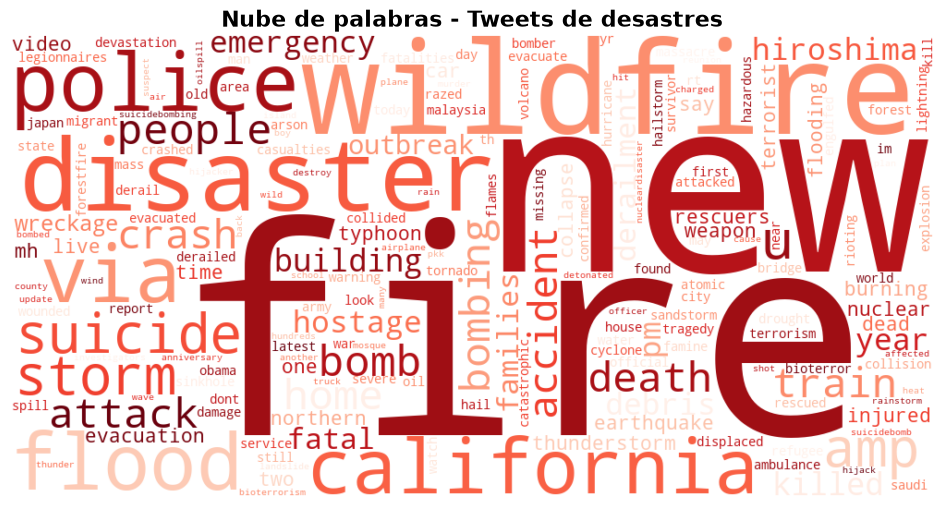

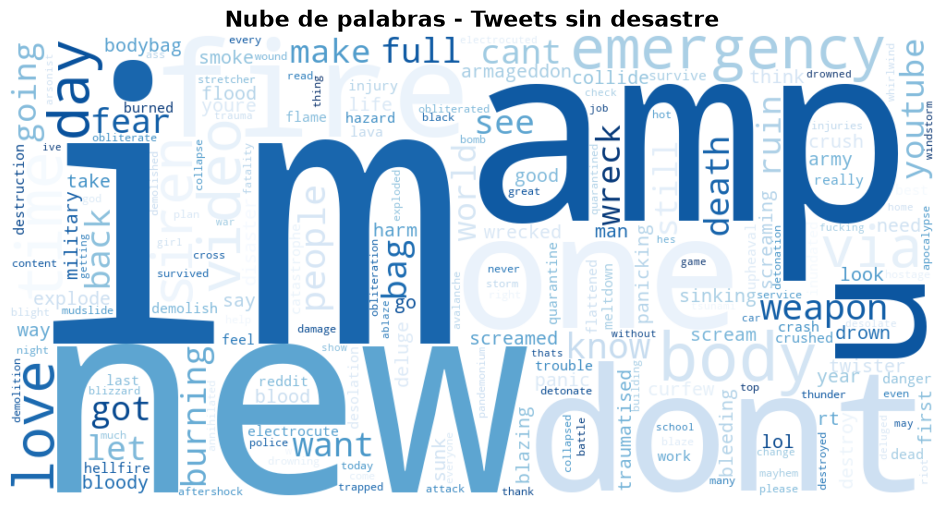

In [7]:
# Nubes de palabras por categoría
def crear_nube(textos, titulo, color):
    texto = ' '.join(textos.dropna())
    nube = WordCloud(width=1000, height=500, background_color='white',
                     colormap=color, collocations=False, min_font_size=10).generate(texto)
    plt.figure(figsize=(14, 6))
    plt.imshow(nube, interpolation='bilinear')
    plt.axis('off')
    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.show()

crear_nube(disaster, 'Nube de palabras - Tweets de desastres', 'Reds')
crear_nube(no_disaster, 'Nube de palabras - Tweets sin desastre', 'Blues')

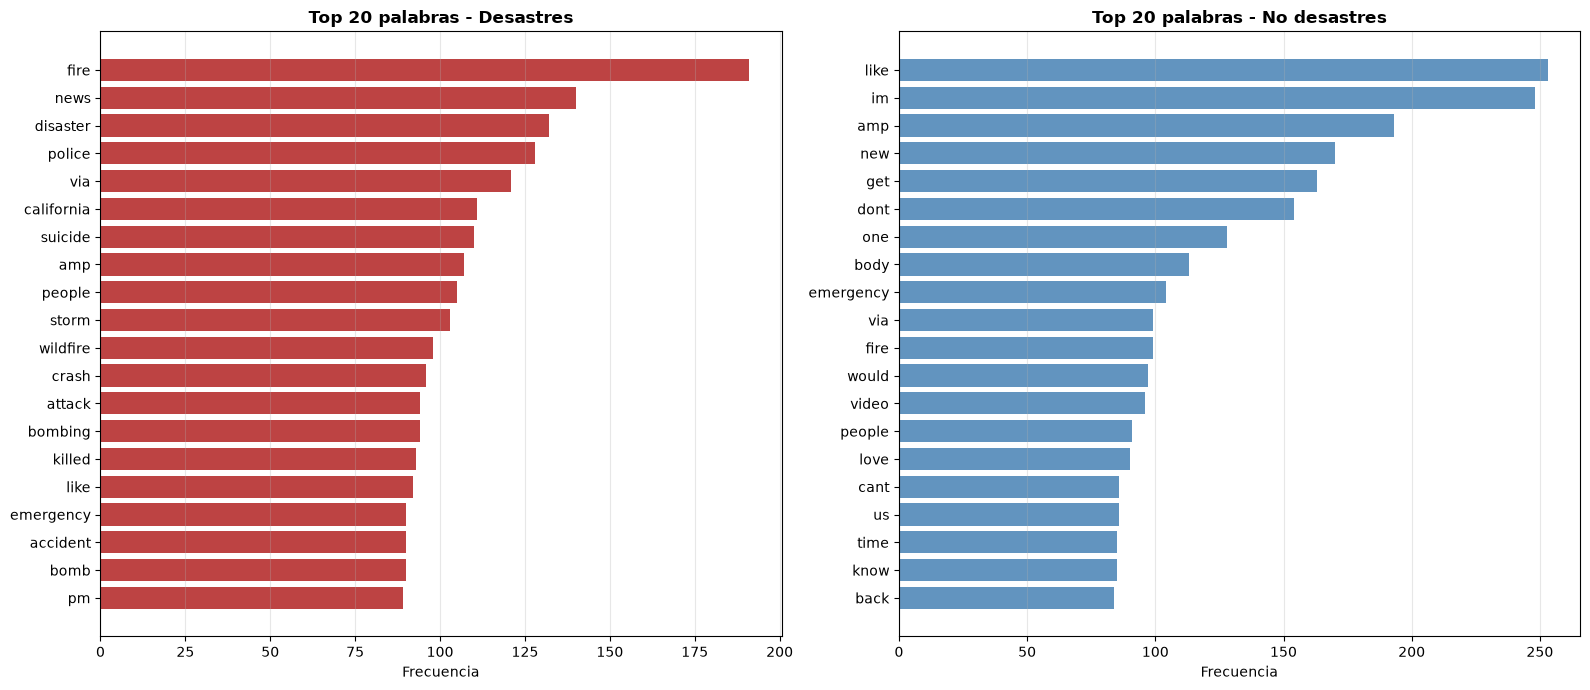

Palabras presentes en ambas categorías (las 20 más frecuentes):
['like', 'amp', 'im', 'fire', 'via', 'get', 'new', 'news', 'people', 'dont', 'one', 'us', 'emergency', 'video', 'disaster', 'police', 'california', 'storm', 'still', 'suicide']
Conclusión: las palabras compartidas ayudan a describir el lenguaje general de los tweets, pero las palabras distintivas y los n-gramas aportan más señal para la clasificación.


In [8]:
# Histograma de las palabras más repetidas en cada categoría
def tabla_frecuencias(textos, n=20):
    return pd.DataFrame(palabras_frecuentes(textos, n), columns=['palabra', 'frecuencia'])

freq_d = tabla_frecuencias(disaster, 20)
freq_nd = tabla_frecuencias(no_disaster, 20)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, tabla, titulo, color in [
    (axes[0], freq_d, 'Desastres', 'firebrick'),
    (axes[1], freq_nd, 'No desastres', 'steelblue')]:
    ax.barh(tabla['palabra'][::-1], tabla['frecuencia'][::-1], color=color, alpha=.85)
    ax.set_title(f'Top 20 palabras - {titulo}', fontweight='bold')
    ax.set_xlabel('Frecuencia')
    ax.grid(axis='x', alpha=.3)
plt.tight_layout()
plt.show()

# Palabras compartidas y palabras distintivas por categoría
compartidas = sorted(set(disaster_word_freq) & set(no_disaster_word_freq),
                     key=lambda w: disaster_word_freq[w] + no_disaster_word_freq[w], reverse=True)
print('Palabras presentes en ambas categorías (las 20 más frecuentes):')
print(compartidas[:20])
print('Conclusión: las palabras compartidas ayudan a describir el lenguaje general de los tweets,',
      'pero las palabras distintivas y los n-gramas aportan más señal para la clasificación.')

## Inciso 6. Modelos de clasificación

Se separa el conjunto de entrenamiento en entrenamiento y validación estratificada. Para abordar el contexto se utiliza TF-IDF con unigramas y bigramas; así el modelo considera tanto palabras individuales como expresiones de dos palabras. Se comparan Naive Bayes Multinomial, Regresión Logística y SVM lineal usando las mismas representaciones y métricas.

Tamaño entrenamiento: 6090 | validación: 1523


,modelo,accuracy,precision,recall,f1
0,Naive Bayes,0.8234,0.8612,0.7018,0.7734
1,Regresión Logística,0.8162,0.8224,0.7294,0.7731
2,SVM lineal,0.7978,0.7772,0.7416,0.7590



Mejor modelo según F1: Naive Bayes
              precision    recall  f1-score   support

 No desastre       0.80      0.91      0.86       869
    Desastre       0.86      0.70      0.77       654

    accuracy                           0.82      1523
   macro avg       0.83      0.81      0.81      1523
weighted avg       0.83      0.82      0.82      1523



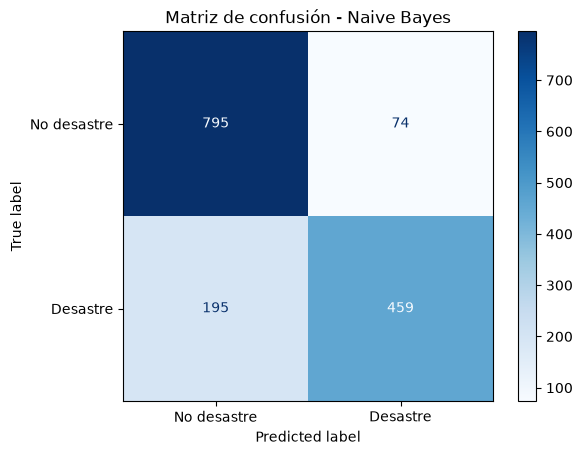

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

X = train_df['cleaned_text'].fillna('')
y = train_df['target']
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

def crear_pipeline(clasificador):
    return Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True,
                                  max_features=100000)),
        ('modelo', clasificador)
    ])

modelos = {
    'Naive Bayes': crear_pipeline(MultinomialNB(alpha=0.5)),
    'Regresión Logística': crear_pipeline(LogisticRegression(max_iter=1000, C=2.0)),
    'SVM lineal': crear_pipeline(LinearSVC(C=1.0))
}

resultados = []
predicciones = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_valid)
    predicciones[nombre] = pred
    resultados.append({
        'modelo': nombre,
        'accuracy': accuracy_score(y_valid, pred),
        'precision': precision_score(y_valid, pred),
        'recall': recall_score(y_valid, pred),
        'f1': f1_score(y_valid, pred)
    })

resultados_df = pd.DataFrame(resultados).sort_values('f1', ascending=False).reset_index(drop=True)
print('Tamaño entrenamiento:', len(X_train), '| validación:', len(X_valid))
display(resultados_df.round(4))

mejor_nombre = resultados_df.loc[0, 'modelo']
mejor_modelo = modelos[mejor_nombre]
print()
print(f'Mejor modelo según F1: {mejor_nombre}')
print(classification_report(y_valid, predicciones[mejor_nombre], target_names=['No desastre', 'Desastre']))

ConfusionMatrixDisplay.from_predictions(
    y_valid, predicciones[mejor_nombre], display_labels=['No desastre', 'Desastre'], cmap='Blues')
plt.title(f'Matriz de confusión - {mejor_nombre}')
plt.show()

## Inciso 7. Función para clasificar un nuevo tweet

La función recibe el texto sin preprocesar, aplica exactamente la misma limpieza usada durante el entrenamiento y devuelve la clase predicha. El modelo se vuelve a entrenar con todos los datos disponibles antes de utilizarlo para nuevos tweets.

In [10]:
# Entrenamiento final con todos los tweets etiquetados
mejor_modelo.fit(X, y)

def clasificar_tweet(tweet):
    texto_limpio = preprocesamiento(tweet)
    prediccion = int(mejor_modelo.predict([texto_limpio])[0])
    etiqueta = 'desastre real' if prediccion == 1 else 'no desastre'
    return {'tweet': tweet, 'texto_procesado': texto_limpio,
            'clasificacion': etiqueta, 'clase': prediccion}

ejemplos = [
    'Massive earthquake destroys buildings and rescue teams are searching for survivors',
    'I had an amazing day at the beach with my friends'
]
for ejemplo in ejemplos:
    print(clasificar_tweet(ejemplo))

{'tweet': 'Massive earthquake destroys buildings and rescue teams are searching for survivors', 'texto_procesado': 'massive earthquake destroys buildings rescue teams searching survivors', 'clasificacion': 'desastre real', 'clase': 1}
{'tweet': 'I had an amazing day at the beach with my friends', 'texto_procesado': 'amazing day beach friends', 'clasificacion': 'no desastre', 'clase': 0}


### Cierre de la primera parte

Los modelos incorporan contexto mediante bigramas TF-IDF. La comparación debe hacerse con F1 además de accuracy, porque las clases no tienen exactamente la misma frecuencia. La función final utiliza el mejor modelo seleccionado en la validación y queda lista para clasificar tweets nuevos.